In [6]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

data = []
for tr in table.find_all('tr'):
    tds = list(tr.find_all('td'))

    for td in tds:
        if td.find('a'):
            point = td.find('a').text
            temperature = tds[5].text
            humidity = tds[10].text

            data.append([point, temperature, humidity])

data
       




[['강릉', '2.7', '70'],
 ['강진군', '4.9', '53'],
 ['강화', '2.0', '37'],
 ['거제', '6.4', '41'],
 ['거창', '3.5', '37'],
 ['경주시', '3.1', '62'],
 ['고산', '8.4', '51'],
 ['고창', '1.0', '64'],
 ['고창군', '2.5', '61'],
 ['고흥', '5.5', '39'],
 ['광양시', '7.1', '29'],
 ['광주', '4.4', '47'],
 ['구미', '3.4', '36'],
 ['군산', '1.9', '64'],
 ['금산', '1.6', '53'],
 ['김해시', '8.1', '20'],
 ['남원', '3.3', '53'],
 ['남해', '6.1', '34'],
 ['대관령', '-1.2', '53'],
 ['대구', '7.2', '26'],
 ['대전', '2.3', '41'],
 ['동두천', '1.0', '41'],
 ['동해', '3.2', '71'],
 ['목포', '2.9', '72'],
 ['문경', '2.1', '42'],
 ['밀양', '5.1', '29'],
 ['백령도', '1.5', '55'],
 ['보령', '2.0', '49'],
 ['보성군', '7.0', '33'],
 ['보은', '1.7', '46'],
 ['봉화', '0.6', '57'],
 ['부산', '8.2', '41'],
 ['부안', '2.2', '76'],
 ['부여', '1.9', '54'],
 ['북강릉', '1.2', '78'],
 ['북부산', '5.1', '26'],
 ['북창원', '8.3', '24'],
 ['북춘천', '-1.0', '65'],
 ['산청', '5.7', '32'],
 ['상주', '2.2', '41'],
 ['서귀포', '12.2', '42'],
 ['서산', '-0.8', '70'],
 ['서울', '2.4', '58'],
 ['성산', '7.6', '58'],
 ['세종', '2.3',

In [7]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [8]:
# matplotlib.pyplot의 show 함수를 호출하지 않아도 주피터 노트북 안에서 그래프가 표시됨
# %matplotlib inline
import pandas as pd # 데이터 처리

df = pd.read_csv('weather.csv', index_col='point') # csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
df



,temperature,humidity
point,,
강릉,2.7,70
강진군,4.9,53
강화,2.0,37
거제,6.4,41
거창,3.5,37
...,...,...
합천,4.4,32
해남,2.2,72
홍성,0.6,62


In [9]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '부산', '울산']]
city_df    # city_df 표시

,temperature,humidity
point,,
서울,2.4,58
인천,1.7,54
대전,2.3,41
대구,7.2,26
광주,4.4,47
부산,8.2,41
울산,6.4,33


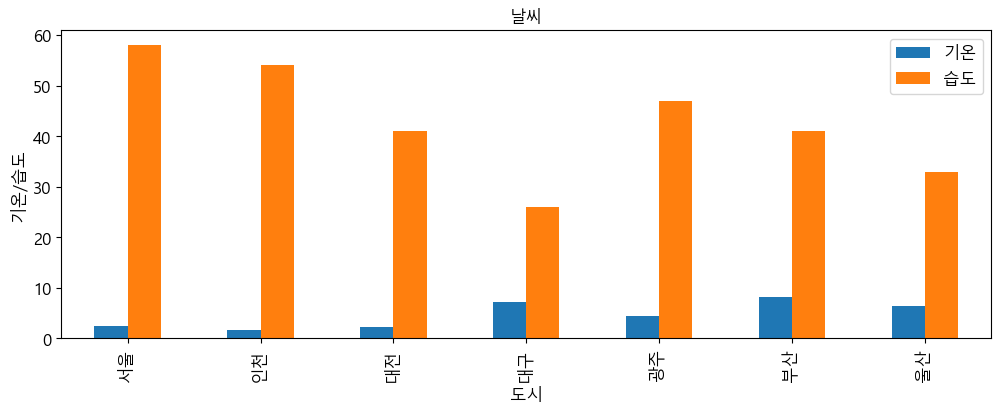

In [11]:
# Windows 한글 폰트 설정
# pip install matplotlib
import matplotlib as mpl

font_name = mpl.font_manager.FontProperties(fname='C:/Windows/Fonts/malgun.ttf').get_name()
mpl.rc('font', family=font_name)

# 차트 종류, 제목, 차트 크기, 범례, 폰트 크기 설정
ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)          # x축 정보 표시
ax.set_ylabel('기온/습도', fontsize=12)     # y축 정보 표시
ax.legend(['기온', '습도'], fontsize=12)    # 범례 지정

# import matplotlib.pyplot as plt # IDLE, 파이썬 인터프리터에서 그래프 표시
# plt.show()